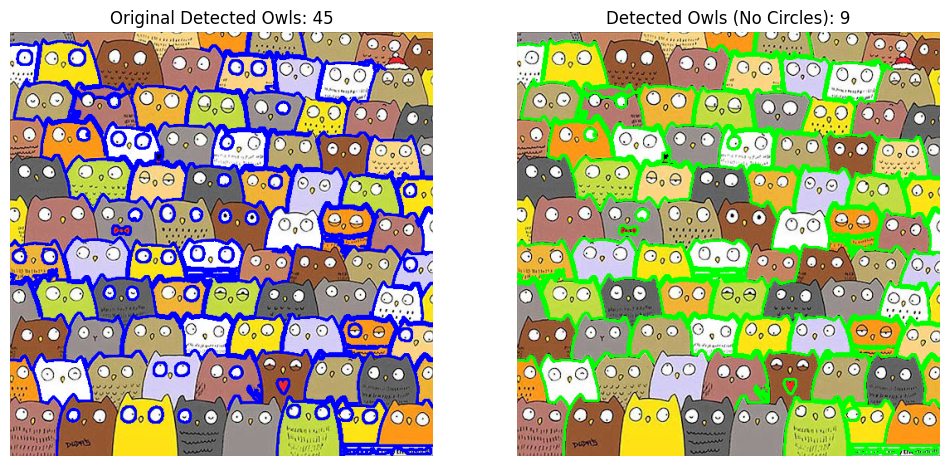

9

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh từ đường dẫn
image_path = "/Users/kaiser_1/Documents/GitHub/Image-processing-and-analysis/midterm/image/cat.jpg"  # Thay thế bằng đường dẫn ảnh thực tế
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Áp dụng bộ lọc để phát hiện cạnh
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

# Tìm contours
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Lọc bỏ các contours nhỏ
min_contour_area = 150  # Giữ lại các cú nhỏ
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_contour_area]

# Tạo bản sao ảnh để vẽ kết quả
result_image = image.copy()
cv2.drawContours(result_image, filtered_contours, -1, (255, 0, 0), 2)

# Hàm tính độ tròn của một contour
def circularity(contour):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    if perimeter == 0:
        return 0
    return (4 * np.pi * area) / (perimeter ** 2)

# Ngưỡng để xác định hình tròn (mắt cú)
circularity_threshold = 0.75

# Lọc bỏ các hình tròn (mắt cú)
filtered_contours_no_circles = [
    cnt for cnt in filtered_contours 
    if circularity(cnt) < circularity_threshold
]

# Vẽ contours sau khi loại bỏ hình tròn
result_image_no_circles = image.copy()
cv2.drawContours(result_image_no_circles, filtered_contours_no_circles, -1, (0, 255, 0), 2)

# Số lượng cú sau khi loại bỏ hình tròn
num_owls_no_circles = len(filtered_contours_no_circles)

# Hiển thị kết quả
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
ax[0].set_title(f"Original Detected Owls: {len(filtered_contours)}")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(result_image_no_circles, cv2.COLOR_BGR2RGB))
ax[1].set_title(f"Detected Owls (No Circles): {num_owls_no_circles}")
ax[1].axis("off")

plt.show()

# Trả về số lượng cú sau khi loại bỏ hình tròn
num_owls_no_circles


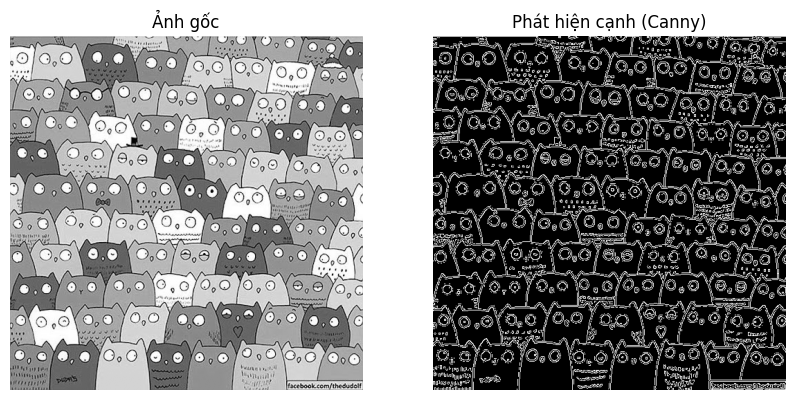

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh
image_path = "/Users/kaiser_1/Documents/GitHub/Image-processing-and-analysis/midterm/image/cat.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Phát hiện cạnh bằng thuật toán Canny
edges = cv2.Canny(image, 100, 200)

# Hiển thị ảnh gốc và ảnh cạnh
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Phát hiện cạnh (Canny)")
plt.axis("off")

plt.show()


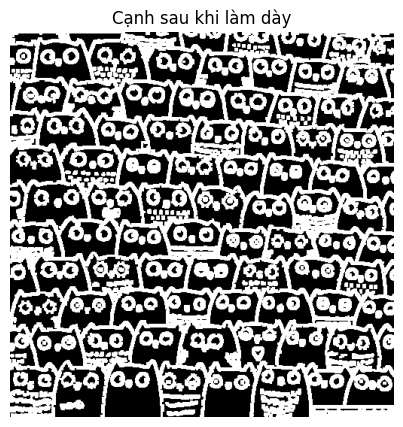

In [4]:
# Làm dày đường viền bằng phép toán giãn nở (Dilation)
kernel = np.ones((3,3), np.uint8)  # Kernel 3x3 để làm dày cạnh
edges_dilated = cv2.dilate(edges, kernel, iterations=1)

# Hiển thị ảnh cạnh đã làm dày
plt.figure(figsize=(5, 5))
plt.imshow(edges_dilated, cmap="gray")
plt.title("Cạnh sau khi làm dày")
plt.axis("off")
plt.show()


In [5]:
# Đọc ảnh gốc và ảnh đen trắng vừa tải lên
image_rgb = cv2.imread("/Users/kaiser_1/Documents/GitHub/Image-processing-and-analysis/midterm/image/cat.jpg", cv2.IMREAD_COLOR)
image_bw = cv2.imread(edges_dilated, cv2.IMREAD_GRAYSCALE)  # Ảnh đen trắng

# Chuyển ảnh đen trắng thành ảnh 3 kênh để thực hiện phép trừ với ảnh màu
image_bw_color = cv2.cvtColor(image_bw, cv2.COLOR_GRAY2BGR)

# Thực hiện phép trừ ảnh gốc - ảnh đen trắng
result_subtract = cv2.subtract(image_rgb, image_bw_color)

# Hiển thị kết quả
plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(result_subtract, cv2.COLOR_BGR2RGB))
plt.title("Ảnh gốc trừ đi ảnh đen trắng")
plt.axis("off")
plt.show()


error: OpenCV(4.11.0) :-1: error: (-5:Bad argument) in function 'imread'
> Overload resolution failed:
>  - Expected 'filename' to be a str or path-like object
>  - Expected 'filename' to be a str or path-like object
>  - Expected 'filename' to be a str or path-like object


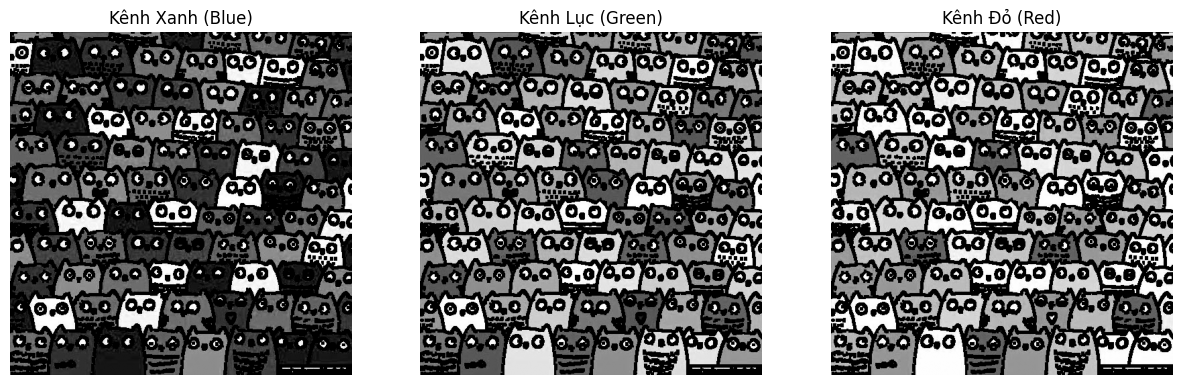

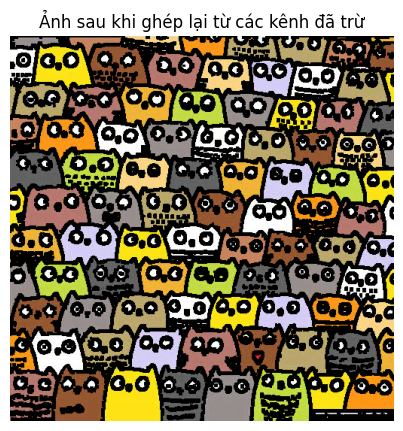

In [7]:
# Tách từng kênh màu từ ảnh gốc
image_rgb = cv2.imread("/Users/kaiser_1/Documents/GitHub/Image-processing-and-analysis/midterm/image/cat.jpg", cv2.IMREAD_COLOR)
blue_channel, green_channel, red_channel = cv2.split(image_rgb)

# Trừ từng kênh màu với ảnh đen trắng
blue_subtract = cv2.subtract(blue_channel, edges_dilated)
green_subtract = cv2.subtract(green_channel, edges_dilated)
red_subtract = cv2.subtract(red_channel, edges_dilated)

image_merged = cv2.merge((blue_subtract, green_subtract, red_subtract))
# Hiển thị kết quả từng kênh sau khi trừ
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(blue_subtract, cmap="gray")
axs[0].set_title("Kênh Xanh (Blue)")

axs[1].imshow(green_subtract, cmap="gray")
axs[1].set_title("Kênh Lục (Green)")

axs[2].imshow(red_subtract, cmap="gray")
axs[2].set_title("Kênh Đỏ (Red)")

for ax in axs:
    ax.axis("off")

plt.show()
plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(image_merged, cv2.COLOR_BGR2RGB))
plt.title("Ảnh sau khi ghép lại từ các kênh đã trừ")
plt.axis("off")
plt.show()


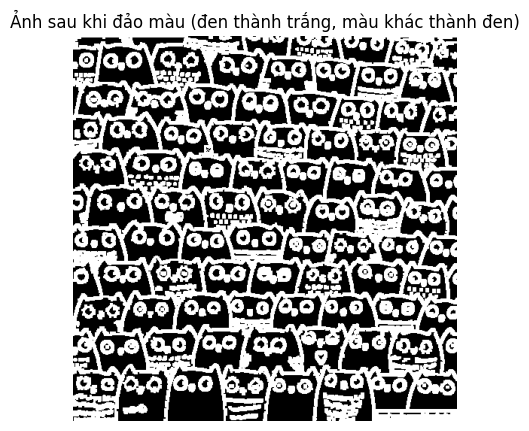

In [8]:
# Chuyển đổi ảnh: màu đen thành trắng, màu khác thành đen
image_binary = cv2.threshold(cv2.cvtColor(image_merged, cv2.COLOR_BGR2GRAY), 1, 255, cv2.THRESH_BINARY_INV)[1]

# Hiển thị kết quả
plt.figure(figsize=(5, 5))
plt.imshow(image_binary, cmap="gray")
plt.title("Ảnh sau khi đảo màu (đen thành trắng, màu khác thành đen)")
plt.axis("off")
plt.show()


In [30]:
# Tìm các thành phần liên thông (vùng màu đen) trong ảnh nhị phân
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(image_binary, connectivity=8)

# Lọc các vùng có diện tích lớn hơn 10
area_threshold = 120
large_black_regions = sum(1 for stat in stats if stat[cv2.CC_STAT_AREA] > area_threshold)

# Hiển thị số lượng vùng màu đen có diện tích lớn hơn 10
large_black_regions


94

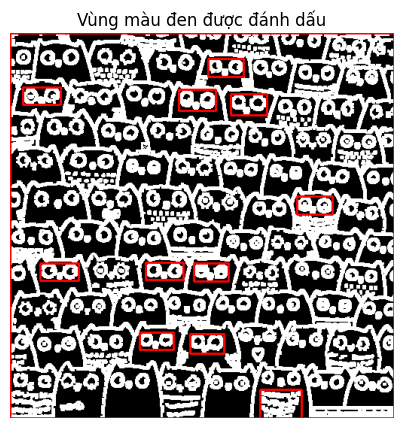

In [29]:
# Tạo ảnh màu để vẽ đánh dấu
image_marked = cv2.cvtColor(image_binary, cv2.COLOR_GRAY2BGR)

# Duyệt qua các vùng và đánh dấu những vùng có diện tích lớn hơn 10
for i in range(1, num_labels):  # Bỏ qua label 0 (nền)
    area = stats[i, cv2.CC_STAT_AREA]
    if area > area_threshold:
        x, y, w, h = stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP], stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
        cv2.rectangle(image_marked, (x, y), (x + w, y + h), (0, 0, 255), 2)  # Vẽ hình chữ nhật đỏ

# Hiển thị kết quả
plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(image_marked, cv2.COLOR_BGR2RGB))
plt.title("Vùng màu đen được đánh dấu")
plt.axis("off")
plt.show()


### test hsv


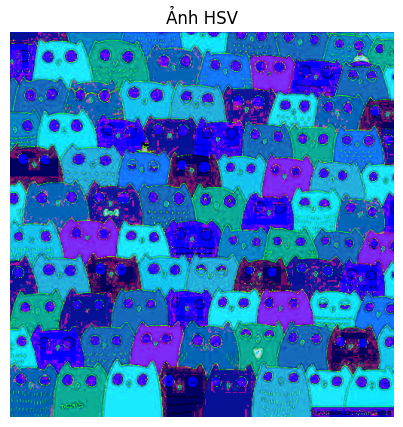

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_image(title, img):
    plt.figure(figsize=(10, 5))
    plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    plt.axis("off")
    plt.title(title)
    plt.show()
    
# Đọc ảnh từ đường dẫn
image_path = "/Users/kaiser_1/Documents/GitHub/Image-processing-and-analysis/midterm/image/cat.jpg"  # Thay thế bằng đường dẫn ảnh thực tế
image = cv2.imread(image_path)
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
show_image("Ảnh HSV", image_hsv)

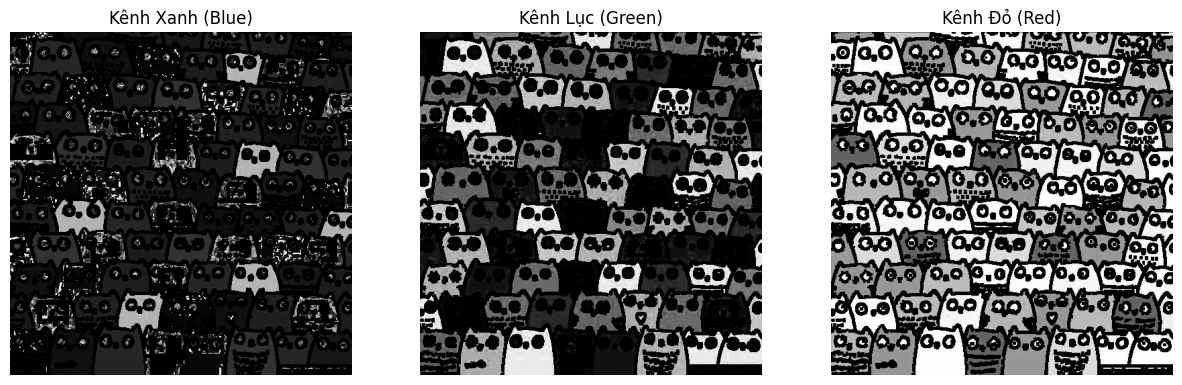

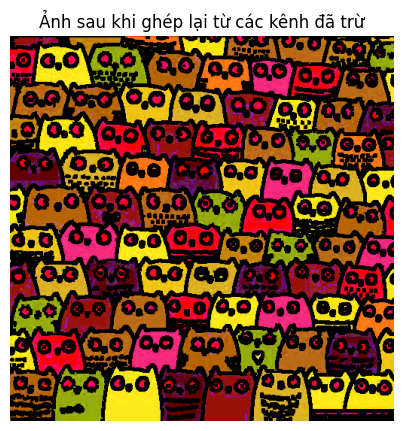

In [33]:

blue_channel, green_channel, red_channel = cv2.split(image_hsv)

# Trừ từng kênh màu với ảnh đen trắng
blue_subtract = cv2.subtract(blue_channel, edges_dilated)
green_subtract = cv2.subtract(green_channel, edges_dilated)
red_subtract = cv2.subtract(red_channel, edges_dilated)

image_merged = cv2.merge((blue_subtract, green_subtract, red_subtract))
# Hiển thị kết quả từng kênh sau khi trừ
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(blue_subtract, cmap="gray")
axs[0].set_title("Kênh Xanh (Blue)")

axs[1].imshow(green_subtract, cmap="gray")
axs[1].set_title("Kênh Lục (Green)")

axs[2].imshow(red_subtract, cmap="gray")
axs[2].set_title("Kênh Đỏ (Red)")

for ax in axs:
    ax.axis("off")

plt.show()
plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(image_merged, cv2.COLOR_BGR2RGB))
plt.title("Ảnh sau khi ghép lại từ các kênh đã trừ")
plt.axis("off")
plt.show()

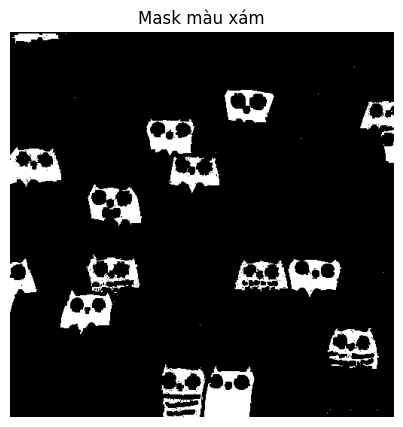

In [37]:
lower_gray = np.array([0, 0, 90])
upper_gray = np.array([180, 50, 200])
mask = cv2.inRange(image_merged, lower_gray, upper_gray)
show_image("Mask màu xám", mask)